In [19]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_score, recall_score, accuracy_score, confusion_matrix, classification_report
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

In [2]:
data_path = 'targets_features_split.parquet'

cols = pq.ParquetFile(data_path).schema.names

print(cols)

['FlightDate', 'split', 'target', 'target_cancelled', 'target_delayed', 'target_delayed_non_cancelled', 'dep_hour', 'Distance', 'tmpf', 'vsby', 'sknt', 'p01i', 'relh', 'gust', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'is_early_morning', 'is_evening', 'is_summer', 'is_holiday_season', 'high_wind', 'low_visibility', 'precip_light', 'precip_moderate', 'precip_heavy', 'Airline_enc', 'Origin_enc', 'region_enc', 'airline_delay_rate', 'airline_cancel_rate', 'airport_delay_rate', 'airport_cancel_rate', 'lag1_delay_rate', 'lag1_cancel_rate', 'lag1_volume', 'cancelled_yesterday', 'hourly_flights', 'weather_severity', 'weather_source_enc']


In [3]:
# split into target
id_cols = ['FlightDate', 'split']

target_cols = [
    'target', # just in case we want to show multiclass
    'target_cancelled', 
    'target_delayed',
    'target_delayed_non_cancelled', # for binary classification delayed vs. on-time

]
# features 
feature_cols = [c for c in cols if c not in set(id_cols + target_cols)]
print('ID columns:\n', id_cols)
print('\nTarget columns:\n', target_cols)
print('\nFeature columns:\n', feature_cols)

ID columns:
 ['FlightDate', 'split']

Target columns:
 ['target', 'target_cancelled', 'target_delayed', 'target_delayed_non_cancelled']

Feature columns:
 ['dep_hour', 'Distance', 'tmpf', 'vsby', 'sknt', 'p01i', 'relh', 'gust', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'is_early_morning', 'is_evening', 'is_summer', 'is_holiday_season', 'high_wind', 'low_visibility', 'precip_light', 'precip_moderate', 'precip_heavy', 'Airline_enc', 'Origin_enc', 'region_enc', 'airline_delay_rate', 'airline_cancel_rate', 'airport_delay_rate', 'airport_cancel_rate', 'lag1_delay_rate', 'lag1_cancel_rate', 'lag1_volume', 'cancelled_yesterday', 'hourly_flights', 'weather_severity', 'weather_source_enc']


In [4]:
all_cols = id_cols + feature_cols + target_cols
df = pd.read_parquet(data_path, columns=all_cols)

print('shape:', df.shape)

# train/val/test split
print('split counts:')
print(df['split'].value_counts(dropna=False))

shape: (24165691, 41)
split counts:
split
train    13777101
val       6310951
test      4077639
Name: count, dtype: int64


In [5]:
# train: 2018-2019| val: 2021| test: 2022

# function to maintain this split
train = df['split'] == 'train'# find the train (2018-2019)
valid = df['split'] == 'val' # 2021
test = df['split'] == 'test' # 2022

# get split
X_train = df.loc[train, feature_cols]
X_val = df.loc[valid, feature_cols]
X_test = df.loc[test, feature_cols]

print('Train rows:', len(X_train))
print('Val rows:', len(X_val))
print('Test rows:', len(X_test))

Train rows: 13777101
Val rows: 6310951
Test rows: 4077639


In [6]:
# class weight for imbalance
def compute_class_weight_ratio(y):
    y = np.asarray(y).astype(int)
    pos = int(y.sum())
    neg = int((1-y).sum())
    return neg / max(pos, 1)

# to show metrics
def print_metrics(split_name, y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    print(f'\n{split_name} results')
    print(f'ROC-AUC: {roc_auc_score(y_true, y_prob)}')
    print(f'PR-AUC: {average_precision_score(y_true, y_prob)}')
    print(f'F1 score: {f1_score(y_true, y_pred)}')
    print(f'Precision: {precision_score(y_true, y_pred)}')
    print(f'Recall: {recall_score(y_true, y_pred)}')
    print(f'Accuracy: {accuracy_score(y_true, y_pred)}')
    print('Confusion matrix:')
    print(confusion_matrix(y_true, y_pred))
    


In [7]:
# Model A: Cancelled vs Not Cancelled

# targets
y_train_c = df.loc[train, 'target_cancelled'].astype(int)
y_val_c = df.loc[valid, 'target_cancelled'].astype(int)
y_test_c = df.loc[test, 'target_cancelled'].astype(int)

# class_weight on train
cancel_class_weight = compute_class_weight_ratio(y_train_c)

# xgb
model_A = XGBClassifier(
     n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
    scale_pos_weight=cancel_class_weight,
)

# fit model
model_A.fit(X_train, y_train_c)

# predicted probability
p_train_c = model_A.predict_proba(X_train)[:,1]
p_val_c = model_A.predict_proba(X_val)[:, 1]
p_test_c = model_A.predict_proba(X_test)[:, 1]

# is probability >= 0.5 === predicted CANCELLED (boolean into int)

print_metrics('Cancelled (Train):', y_train_c, p_train_c, threshold=0.5)
print_metrics('Cancelled (Validation):', y_val_c, p_val_c, threshold=0.5)
print_metrics('Cancelled (Test):', y_test_c, p_test_c, threshold=0.5)


Cancelled (Train): results
ROC-AUC: 0.8430883284488251
PR-AUC: 0.20018582569734983
F1 score: 0.10106522990754897
Precision: 0.05418472769499713
Recall: 0.7497293142351784
Accuracy: 0.7657503563340358
Confusion matrix:
[[10368402  3166721]
 [   60560   181418]]

Cancelled (Validation): results
ROC-AUC: 0.7647637816367344
PR-AUC: 0.11891156313828265
F1 score: 0.0921777175402578
Precision: 0.05006619160039085
Recall: 0.5801610607671105
Accuracy: 0.7989813262692105
Confusion matrix:
[[4977926 1222011]
 [  46608   64406]]

Cancelled (Test): results
ROC-AUC: 0.7232647242144173
PR-AUC: 0.14507074308430445
F1 score: 0.10719815788218337
Precision: 0.05822275845601082
Recall: 0.6749356690017939
Accuracy: 0.6603510021362853
Confusion matrix:
[[2609527 1344921]
 [  40045   83146]]


In [8]:
# model B: Delay vs. On-Time (target_delayed_non_cancelled)

# remove cancelled rows (-1) for delayed model
train_delay = train & (df['target_delayed_non_cancelled'] >= 0)
val_delay = valid & (df['target_delayed_non_cancelled'] >= 0)
test_delay = test & (df['target_delayed_non_cancelled'] >= 0)

X_train_d = df.loc[train_delay, feature_cols]
X_val_d = df.loc[val_delay, feature_cols]
X_test_d = df.loc[test_delay, feature_cols]

y_train_d = df.loc[train_delay, 'target_delayed_non_cancelled'].astype(int)
y_val_d = df.loc[val_delay, 'target_delayed_non_cancelled'].astype(int)
y_test_d = df.loc[test_delay, 'target_delayed_non_cancelled'].astype(int)

delay_class_weight = compute_class_weight_ratio(y_train_d)

model_B = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    n_jobs=-1,
    random_state=42,
    scale_pos_weight=delay_class_weight,
    
)

model_B.fit(X_train_d, y_train_d)

p_train_d = model_B.predict_proba(X_train_d)[:, 1]
p_val_d = model_B.predict_proba(X_val_d)[:,1]
p_test_d = model_B.predict_proba(X_test_d)[:,1]

print_metrics('Delay (non-cancelled: Train):', y_train_d, p_train_d, threshold=0.5)
print_metrics('Delay (nc: Validation):', y_val_d, p_val_d, threshold=0.5)
print_metrics('Delayed (nc: Test):', y_test_d, p_test_d, threshold=0.5)


Delay (non-cancelled: Train): results
ROC-AUC: 0.7098470820809923
PR-AUC: 0.37776388336029265
F1 score: 0.4115676369051495
Precision: 0.3020187819412926
Recall: 0.6458211853487218
Accuracy: 0.6541686396200463
Confusion matrix:
[[7217281 3783128]
 [ 897742 1636972]]

Delay (nc: Validation): results
ROC-AUC: 0.7090674246172233
PR-AUC: 0.3615983360689519
F1 score: 0.398202072935968
Precision: 0.2938629391972071
Recall: 0.6174255063332432
Accuracy: 0.6770481700055985
Confusion matrix:
[[3535214 1591813]
 [ 410468  662442]]

Delayed (nc: Test): results
ROC-AUC: 0.6988060012525984
PR-AUC: 0.3999052912005066
F1 score: 0.43962321541658184
Precision: 0.3238800746488902
Recall: 0.6840938663379128
Accuracy: 0.6193736774386716
Confusion matrix:
[[1858869 1232522]
 [ 272645  590412]]


## Feature Importance for Models A & B

Top 40 features - Model A (Cancellation)
lag1_cancel_rate       0.127082
cancelled_yesterday    0.118136
airline_cancel_rate    0.113990
weather_severity       0.097342
p01i                   0.055340
is_holiday_season      0.033463
airport_cancel_rate    0.030687
is_evening             0.029768
is_summer              0.028402
airline_delay_rate     0.025544
tmpf                   0.023655
dep_hour               0.023586
month_sin              0.022522
region_enc             0.021483
month_cos              0.021006
relh                   0.019343
weather_source_enc     0.018428
dow_sin                0.018249
Distance               0.015365
dow_cos                0.014916
Airline_enc            0.014545
vsby                   0.014286
lag1_delay_rate        0.012977
gust                   0.012794
lag1_volume            0.011956
hourly_flights         0.010465
low_visibility         0.010367
airport_delay_rate     0.010168
sknt                   0.009954
high_wind              0.008303

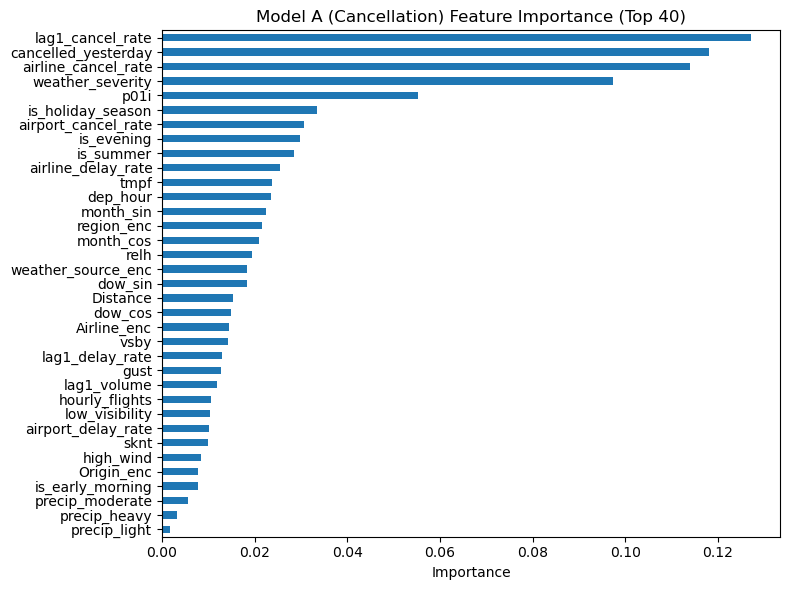

Top 20 features - Model B (Delay vs. On-time)
is_early_morning       0.404106
is_evening             0.122998
dep_hour               0.111229
lag1_delay_rate        0.059041
weather_severity       0.034843
is_summer              0.032591
airline_delay_rate     0.032042
p01i                   0.024027
lag1_cancel_rate       0.016559
relh                   0.014251
month_cos              0.011634
airport_delay_rate     0.010666
dow_sin                0.009895
region_enc             0.009355
airline_cancel_rate    0.009334
airport_cancel_rate    0.008887
weather_source_enc     0.007656
month_sin              0.007278
tmpf                   0.007277
Distance               0.006897
dtype: float32


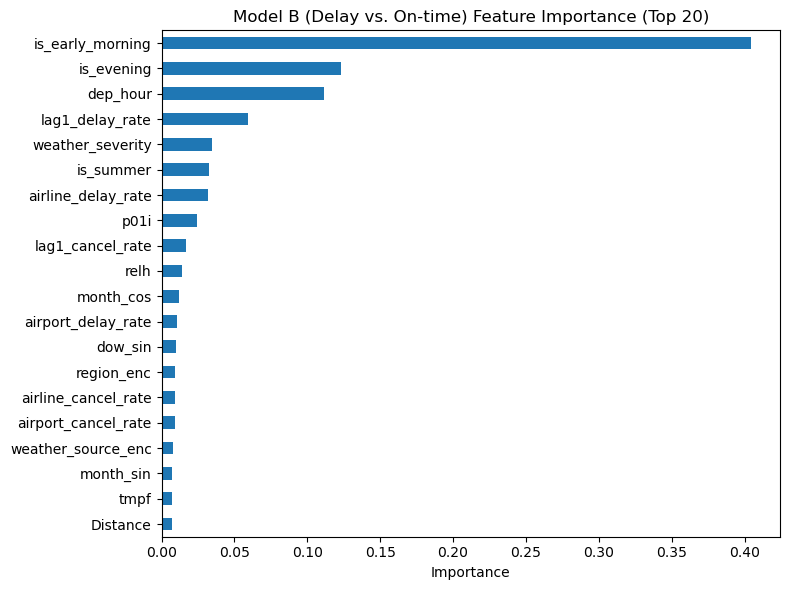

In [14]:
def show_feat_importance(model, feature_cols, model_name, top_n=20):
    importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

    print(f'Top {top_n} features - {model_name}')
    print(importance.head(top_n))

    plt.figure(figsize=(8,6))
    importance.head(top_n).sort_values().plot(kind='barh')
    plt.title(f'{model_name} Feature Importance (Top {top_n})')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

    return importance 

imp_A = show_feat_importance(model_A, feature_cols, 'Model A (Cancellation)', top_n=40)
imp_B = show_feat_importance(model_B, feature_cols, 'Model B (Delay vs. On-time)', top_n=20)









In [17]:
## cascade
# get delay probs on full val/test (not just non-cancelled subset)
p_val_d_full = model_B.predict_proba(X_val)[:, 1]
p_test_d_full = model_B.predict_proba(X_test)[:, 1]

y_val_multi = df.loc[valid, 'target'].astype(int).values
y_test_multi = df.loc[test, 'target'].astype(int).values

y_pred_val_multi = np.where((p_val_c >= 0.5).astype(int) == 1, 2, (p_val_d_full >= 0.5).astype(int))
y_pred_test_multi = np.where((p_test_c >= 0.5).astype(int) == 1, 2, (p_test_d_full >= 0.5).astype(int))


In [21]:
## combining both models (accuracy)
print('Val cascade acc:', accuracy_score(y_val_multi, y_pred_val_multi))
print('Val confusion matrix:')
print(confusion_matrix(y_val_multi, y_pred_val_multi))
print(classification_report(y_val_multi, y_pred_val_multi, digits=4))

print('Test cascade acc:', accuracy_score(y_test_multi, y_pred_test_multi))
print('Test confusion matrix:')
print(confusion_matrix(y_test_multi, y_pred_test_multi))
print(classification_report(y_test_multi, y_pred_test_multi, digits=4))


Val cascade acc: 0.5800296975844053
Val confusion matrix:
[[3197704 1017030  912293]
 [ 364763  398429  309718]
 [  24871   21737   64406]]
              precision    recall  f1-score   support

           0     0.8914    0.6237    0.7339   5127027
           1     0.2772    0.3714    0.3175   1072910
           2     0.0501    0.5802    0.0922    111014

    accuracy                         0.5800   6310951
   macro avg     0.4062    0.5251    0.3812   6310951
weighted avg     0.7722    0.5800    0.6518   6310951

Test cascade acc: 0.4513996947743535
Test confusion matrix:
[[1466415  638332  986644]
 [ 213696  291084  358277]
 [  20317   19728   83146]]
              precision    recall  f1-score   support

           0     0.8624    0.4744    0.6120   3091391
           1     0.3067    0.3373    0.3212    863057
           2     0.0582    0.6749    0.1072    123191

    accuracy                         0.4514   4077639
   macro avg     0.4091    0.4955    0.3468   4077639
weighted av

## Notes for team
---
Model A: Binary classification --> cancelled vs NOT cancelled ('target_cancelled')

- Model B: (binary classification) --> delayed vs. on time on **non-cancelled flights** (target_delayed_non_cancelled)

- class imabalance ---> assigning weights (more weight to positive class)

- Baseline threshold (**Needs to Change**): 0.05

      - threshold  >= 0.5 ---> predicts class 1


- seperately Model B does best at generalizing,

- Model A low precision

- **Cascade**: low (need to work on models seperately to increase)


------

* hyperparameter tuning
* change threshold
* **feature importance DIFFERENT FOR EACH MODEL:** maybe we should use different features, add some features to one, and remove them from the other?

#### Model A
* lag1_cancellation_rate: yesterday's cancellation rate ----> **VERY IMPORTANT**
- **maybe we can do lag rates so for more days up until 7?**
- maybe also the moving average across certain days (average recent history)

#### Model B
* top 3: early morning, evening and departure hour: **Time features**
* need to add is_weekend feature